In [35]:
import numpy as np
import matplotlib.pyplot as plt
import os


In [5]:
def H_matrix_zhou(N, t1, t2, y1, y2):                #周期边条件
    H_matrix = np.zeros((2*N, 2*N), dtype=complex)
    for i in range(2*N):
        if i == 0:
            H_matrix[i,i], H_matrix[i,i+1],H_matrix[i,2*N-1] = y1 + 1j*y2, t1,t2
        elif i == 2*N-1:
            H_matrix[i,0],H_matrix[i,i-1], H_matrix[i,i] = t2,t1, y1 - 1j*y2
        elif i % 2 == 1:  # 奇数
            H_matrix[i,i-1], H_matrix[i,i], H_matrix[i,i+1] = t1, y1 - 1j*y2, t2
        else:  # 偶数
            H_matrix[i,i-1], H_matrix[i,i], H_matrix[i,i+1] = t2, y1 + 1j*y2, t1
    return H_matrix

In [36]:
def H_matrix_kai(N, t1, t2, y1, y2):               #开放边条件
    H_matrix = np.zeros((2*N, 2*N), dtype=complex)
    for i in range(2*N):
        if i == 0:
            H_matrix[i,i], H_matrix[i,i+1] = y1 + 1j*y2, t1
        elif i == 2*N-1:
            H_matrix[i,i-1], H_matrix[i,i] = t1, y1 - 1j*y2
        elif i % 2 == 1:  # 奇数
            H_matrix[i,i-1], H_matrix[i,i], H_matrix[i,i+1] = t1, y1 - 1j*y2, t2
        else:  # 偶数
            H_matrix[i,i-1], H_matrix[i,i], H_matrix[i,i+1] = t2, y1 + 1j*y2, t1
    return H_matrix

In [28]:
# Parameters
t1 = 1
t2 = 4
y1 = 0
y2 = 0
N = 100
#print(np.linalg.det(H_matrix_kai(N, t1, t2, y1, y2)))
H_matrix=H_matrix_kai(N, t1, t2, y1, y2)
Proper_value = np.linalg.eig(H_matrix)[0]
eigenstate = np.linalg.eig(H_matrix)[1]
print(Proper_value,len(Proper_value))
distribution = np.abs(eigenstates) ** 2
prob_dict = {eigenvalues[i]: distribution[:, i] for i in range(len(eigenvalues))}

[ 5.94996735e-15+0.j  4.99960681e+00+0.j  4.99842743e+00+0.j
  4.99646246e+00+0.j  4.99371290e+00+0.j  4.99018015e+00+0.j
  4.98586601e+00+0.j  4.98077267e+00+0.j  4.97490275e+00+0.j
  4.96825924e+00+0.j  4.96084556e+00+0.j  4.95266552e+00+0.j
  4.94372336e+00+0.j  4.93402371e+00+0.j  4.92357163e+00+0.j
  4.91237258e+00+0.j  4.90043245e+00+0.j  4.88775755e+00+0.j
  4.87435461e+00+0.j  4.86023078e+00+0.j  4.84539368e+00+0.j
  4.82985132e+00+0.j  4.74187284e+00+0.j  4.76080544e+00+0.j
  4.77907964e+00+0.j  4.79668516e+00+0.j  4.81361217e+00+0.j
  4.72229259e+00+0.j  4.70207590e+00+0.j  4.65978051e+00+0.j
  4.63772666e+00+0.j  4.61508613e+00+0.j  4.59187259e+00+0.j
  4.56810024e+00+0.j  4.54378382e+00+0.j  4.49358033e+00+0.j
  4.46772542e+00+0.j  4.44139077e+00+0.j  3.00066225e+00+0.j
  3.00264746e+00+0.j  3.00595096e+00+0.j  3.01056506e+00+0.j
  3.01647904e+00+0.j -4.99960681e+00+0.j -4.99842743e+00+0.j
 -4.99646246e+00+0.j -4.99371290e+00+0.j -4.99018015e+00+0.j
 -4.98586601e+00+0.j  4.

图像已保存至: C:\Users\taoji\Desktop\结果\本征值和本征态\本征值\t1=1_t2=1_y1=0_y2=0_N=100.png


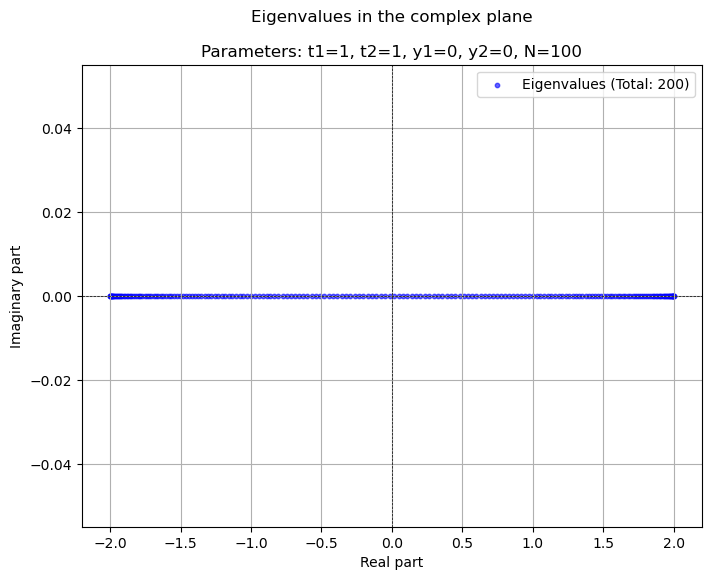

In [37]:
# 参数设置
t1 = 1
t2 = 1
y1 = 0
y2 = 0
N = 100

# 计算哈密顿矩阵和本征值
H = H_matrix_kai(N, t1, t2, y1, y2)
Proper_value = np.linalg.eig(H)[0]

# 绘制复平面上的本征值
plt.figure(figsize=(8, 6))
plt.scatter(Proper_value.real, Proper_value.imag, s=10, c='b', alpha=0.6,
            label=f'Eigenvalues (Total: {len(Proper_value)})')

plt.xlabel('Real part')
plt.ylabel('Imaginary part')
plt.title(f'Eigenvalues in the complex plane\n\n'
          f'Parameters: t1={t1}, t2={t2}, y1={y1}, y2={y2}, N={N}')
plt.grid(True)
plt.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
plt.legend()

# 创建保存路径（如果不存在）
save_dir = r"C:\Users\taoji\Desktop\结果\本征值和本征态\本征值"
os.makedirs(save_dir, exist_ok=True)  # 自动创建文件夹

# 按参数命名文件
filename = f"t1={t1}_t2={t2}_y1={y1}_y2={y2}_N={N}.png"
save_path = os.path.join(save_dir, filename)

# 保存图像
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"图像已保存至: {save_path}")

plt.show(block=False)  # 非阻塞模式（图像窗口不会卡住程序）
plt.close()           # 立即关闭图像窗口（如果不需要显示）


In [39]:
import numpy as np
import matplotlib.pyplot as plt
import os

def H_matrix_kai(N, t1, t2, y1, y2):
    """
    构建开放边界条件下的哈密顿矩阵
    参数:
        N: 晶格单元数
        t1, t2: 跃迁强度
        y1, y2: 在位能实部和虚部
    返回:
        2N×2N的复数哈密顿矩阵
    """
    H_matrix = np.zeros((2*N, 2*N), dtype=complex)
    for i in range(2*N):
        if i == 0:  # 第一个格点
            H_matrix[i,i], H_matrix[i,i+1] = y1 + 1j*y2, t1
        elif i == 2*N-1:  # 最后一个格点
            H_matrix[i,i-1], H_matrix[i,i] = t1, y1 - 1j*y2
        elif i % 2 == 1:  # 奇数格点
            H_matrix[i,i-1], H_matrix[i,i], H_matrix[i,i+1] = t1, y1 - 1j*y2, t2
        else:  # 偶数格点
            H_matrix[i,i-1], H_matrix[i,i], H_matrix[i,i+1] = t2, y1 + 1j*y2, t1
    return H_matrix

# 物理参数设置
#t1 = 1    # 奇数格点间跃迁
#t2 = 4    # 偶数格点间跃迁
#y1 = 0    # 在位能实部
#y2 = 0    # 在位能虚部
#N = 100   # 晶格单元数

# 计算哈密顿矩阵和本征值/本征态
H_matrix = H_matrix_kai(N, t1, t2, y1, y2)
Proper_value = np.linalg.eig(H_matrix)[0]  # 本征值
eigenstate = np.linalg.eig(H_matrix)[1]    # 本征态

# 计算概率分布 |ψ|²
distribution = np.abs(eigenstate) ** 2
prob_dict = {Proper_value[i]: distribution[:, i] for i in range(len(Proper_value))}

# 创建主目录
main_dir = r"C:\Users\taoji\Desktop\结果\本征值和本征态\本征值和空间分布"
param_dir = os.path.join(main_dir, f"t1_{t1}_t2_{t2}_y1_{y1}_y2_{y2}_N_{N}")
os.makedirs(param_dir, exist_ok=True)

# 创建两个子目录
real_dir = os.path.join(param_dir, "实部主导_虚部小于1e-6")
imag_dir = os.path.join(param_dir, "虚部主导_虚部大于1e-6")
os.makedirs(real_dir, exist_ok=True)
os.makedirs(imag_dir, exist_ok=True)

def format_complex_number(c):
    """优化后的复数格式化函数，确保小数值可区分"""
    real_part = np.real(c)
    imag_part = np.imag(c)
    
    # 判断是否为纯实数（虚部接近0）
    if abs(imag_part) < 1e-12:
        return f"{real_part:+.12e}".replace('+', 'p').replace('-', 'm')
    else:
        return (f"{real_part:+.4e}".replace('+', 'p').replace('-', 'm') + 
                f"{imag_part:+.4e}i".replace('+', 'p').replace('-', 'm'))

# 绘制并保存所有本征态分布图
for eig_val, prob_dist in prob_dict.items():
    # 分类本征值
    if abs(np.imag(eig_val)) <= 1e-6:
        save_dir = real_dir
        prefix = "real_"
    else:
        save_dir = imag_dir
        prefix = "imag_"
    
    # 创建图像
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, 2*N+1), prob_dist, 'b-', linewidth=1)
    
    # 设置标题和标签
    title = f"Eigenvalue: {eig_val:.12e}"
    plt.title(title)
    plt.xlabel("Site index n (1-200)")
    plt.ylabel("Probability |ψ|²")
    plt.grid(True, alpha=0.3)
    
    # 生成文件名
    filename = prefix + format_complex_number(eig_val) + ".png"
    save_path = os.path.join(save_dir, filename)
    
    # 保存图像
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()

print(f"所有图像已保存至: {param_dir}")

所有图像已保存至: C:\Users\taoji\Desktop\结果\本征值和本征态\本征值和空间分布\t1_1_t2_1_y1_0_y2_0_N_100
